In [1]:
%pip install networkx pandas matplotlib folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Graph Setup

Goal: represent road network as Python object.
Representation:
- Nodes: Locations that we want to visit or pass through.
- Edges: roads connecting these location, each with a travel time in minutes.


Each edge is a tuple of (origin, destination, travel_time_minutes).
- travel_time_minutes is a estimation - can be obtained via Google Maps API.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from config import get_default_graph, NODE_POS

G = get_default_graph()

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 11, Edges: 13


In [3]:
for u, v, data in G.edges(data=True):
    print(f"  {u} -> {v}: {data['road'].travel_time} min ({data['road'].road_type}, {data['road'].risk} risk)")

  Karatu -> Lodoare Gate: 60 min (main_road, low risk)
  Karatu -> Moru Kopjes: 120 min (main_road, low risk)
  Karatu -> Klein's Gate: 180 min (main_road, low risk)
  Lodoare Gate -> Olduvai Gorge: 45 min (main_road, low risk)
  Olduvai Gorge -> Naabi Hill: 60 min (main_road, low risk)
  Naabi Hill -> Simba Kopjes: 30 min (direct_track, high risk)
  Naabi Hill -> Ndutu: 75 min (direct_track, high risk)
  Simba Kopjes -> Seronera: 45 min (main_road, low risk)
  Ndutu -> Seronera: 90 min (main_road, low risk)
  Moru Kopjes -> Seronera: 45 min (black_cotton, high risk)
  Seronera -> Retima: 60 min (main_road, low risk)
  Retima -> Lobo: 90 min (black_cotton, high risk)
  Lobo -> Klein's Gate: 60 min (main_road, low risk)


In [4]:
edge_labels = {(u, v): data['road'].travel_time for u, v, data in G.edges(data=True)}

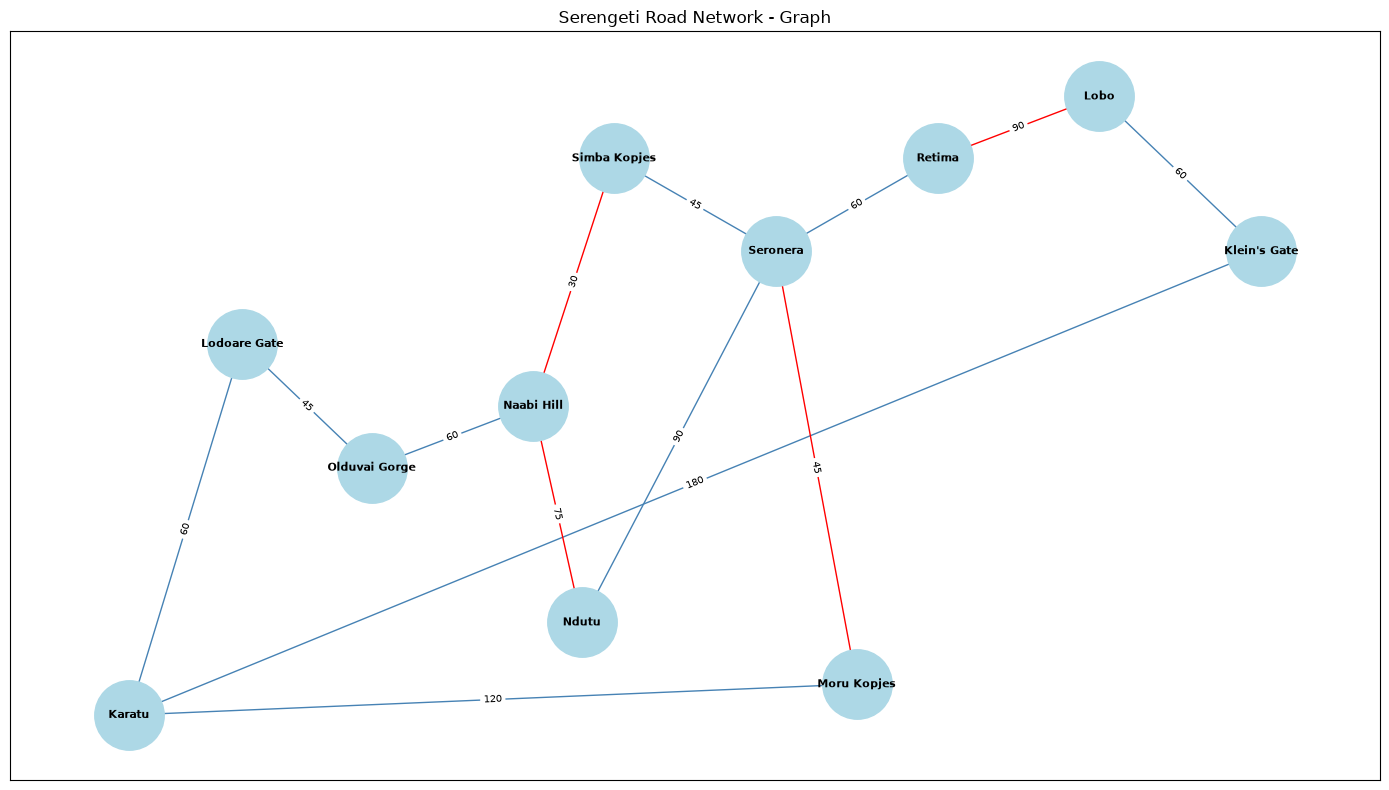

In [5]:
from utils import draw_graph

draw_graph(G, NODE_POS, edge_labels, "Serengeti Road Network - Graph")

In [6]:
print(list(G.neighbors("Karatu")))


for u, v, data in G.edges(data=True):
    print(f"{u} -> {v}: {data}")

['Lodoare Gate', 'Moru Kopjes', "Klein's Gate"]
Karatu -> Lodoare Gate: {'road': Road(travel_time=60, road_type='main_road', risk='low')}
Karatu -> Moru Kopjes: {'road': Road(travel_time=120, road_type='main_road', risk='low')}
Karatu -> Klein's Gate: {'road': Road(travel_time=180, road_type='main_road', risk='low')}
Lodoare Gate -> Olduvai Gorge: {'road': Road(travel_time=45, road_type='main_road', risk='low')}
Olduvai Gorge -> Naabi Hill: {'road': Road(travel_time=60, road_type='main_road', risk='low')}
Naabi Hill -> Simba Kopjes: {'road': Road(travel_time=30, road_type='direct_track', risk='high')}
Naabi Hill -> Ndutu: {'road': Road(travel_time=75, road_type='direct_track', risk='high')}
Simba Kopjes -> Seronera: {'road': Road(travel_time=45, road_type='main_road', risk='low')}
Ndutu -> Seronera: {'road': Road(travel_time=90, road_type='main_road', risk='low')}
Moru Kopjes -> Seronera: {'road': Road(travel_time=45, road_type='black_cotton', risk='high')}
Seronera -> Retima: {'road':